# Z3 Solver Project Demo
Presentation purposes

*Svolto per la presentazione del progetto all'orale*

In [4]:
import itertools 
from model import TimetableScheduler
from z3 import *

## Scenario 1: Next Semester's Courses for AIDA
Simplified model containing sessions and courses for the next semester in AIDA.

*Modello semplificato che contiene i corsi del prossimo semestre del CdS triennale in IADA (2025-2026, Primo Semestre)*

Vincoli aggiuntivi: 
- Non ci sono lezioni il sabato
$$
\forall S, T, A, \text{ s.t. }T\text{ rappresenta un'ora in sabato }(\lfloor T/ \texttt{TimeslotsPerDay} \rfloor = 6), X_{S,T,A} = \text{False} 
$$

- Gli studenti del 1°, 2° e del 3° anno hanno orari di pranzo diversi per evitare il sovraffollamento delle mense (2°, 3° sono raggruppati assieme per semplicità). Ovvero, a loro si garantiscono delle "ore vuote" per pranzare che sono diverse a seconda dell'anno.
    - Si suppone che tramite un sondaggio si è deciso che quelli del 1° anno pranzano alle 12-13 e quelli del 2°, 3° anno alle 13-14

$$
\bigwedge_{\begin{gather*}S,T,A\\ \tiny{T \text{ rappresenta una fascia oraria dalle 12-13}}, \\ \tiny{S\text{ è una sessione di un corso del 1° anno}}\end{gather*}} \neg X_{S,T,A}
$$

e

$$
\bigwedge_{\begin{gather*}S,T,A\\ \tiny{T \text{ rappresenta una fascia oraria dalle 13-14}}, \\ \tiny{S\text{ è una sessione di un corso del 2° e del 3° anno}}\end{gather*}} \neg X_{S,T,A}
$$

- Il rappresentante del corso di studi ha espresso che gli studenti del 3° anno desiderano di avere almeno un giorno privo di lezioni per permettere agli alunni di seguire i corsi a scelta libera (e possibilmente di minimizzare il rischio di sovrapposizioni).

$$
\bigvee_{k=0,1,\ldots,4 }\left( \bigwedge_{\begin{gather*}T\text{ è un timeslot nel giorno }k \\ S,A \in \mathcal S \times \mathcal A\end{gather*}} \neg X_{S,T,A}\right)
$$

In [3]:
orario_aida = TimetableScheduler('aida', 9, 9, optional_constraints=True)

In [10]:
orario_aida.start()

In [11]:
# add custom constraint: no lezioni il sabato
for (S,T,A) in itertools.product(orario_aida.indexes['Sessions'],
                                 orario_aida.T,
                                 orario_aida.indexes['Rooms']):
    if (T // 9) == (6-1):
        orario_aida.solver.add(Not(orario_aida.X[S,T,A]))


In [12]:
# add custom constraint: turnazione delle mense
# osserviamo che i numeri 3, 4 rappresentano le fasce orarie 12-13 e 13-14 del lunedì. Se le sommiamo ad un multiplo di 9 otteniamo la stessa fascia oraria, riferita ad un altro giorno.
courses_1 = orario_aida.database.get_courses(1)
courses_2 = orario_aida.database.get_courses(2)
courses_3 = orario_aida.database.get_courses(3)

i = 3
while i < max(orario_aida.T):
    for course in courses_1:
        orario_aida.solver.add(And([
            Not(orario_aida.X[S,i, A]) for (S,A) in itertools.product(orario_aida.database.get_sessions(course), orario_aida.indexes['Rooms'])
        ]))

    i += 9

i = 4
while i < max(orario_aida.T):
    for course in courses_2:
        orario_aida.solver.add(And([
            Not(orario_aida.X[S,i, A]) for (S,A) in itertools.product(orario_aida.database.get_sessions(course), orario_aida.indexes['Rooms'])
        ]))

    for course in courses_3:
        orario_aida.solver.add(And([
            Not(orario_aida.X[S,i, A]) for (S,A) in itertools.product(orario_aida.database.get_sessions(course), orario_aida.indexes['Rooms'])
        ]))

    i += 9

In [13]:
# quelli del terzo anno desiderano un giorno libero
K = [0,1,2,3,4] # escluso sabato, in quanto è già escluso
sessions = []

for course in courses_3:
    for s in orario_aida.database.get_sessions(course):
        sessions.append(s)

ands = []

for k in K: 
    ands.append(
        And(
            [Not(orario_aida.X[S,T,A]) for (S,T,A) in itertools.product(sessions, range(9*k, 9 + 9*k), orario_aida.indexes['Rooms'])]
        )
    )

orario_aida.solver.add(
    Or(
        ands
    )
)

In [14]:
orario_aida.add_constraints()

In [15]:

orario_aida.solve()

TIME TABLE SUCCESSFULLY CREATED
Saving the schedule in the SQL Database...
Schedule saved


In [16]:
from IPython.display import display, HTML 
df = orario_aida.print_schedule_df()
display(HTML(df.to_html().replace("\\n", "<br>")))

,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
09:00 - 10:00,"> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 2B]> SISTEMI COMPLESSI [H2 Bis, 5C]","> ANALISI 1 [H3, 1B]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 1C]","> COMPUTABILITà, COMPLESSITà E LOGICA [H2 Bis, 2A MORIN]","> INTRODUZIONE AL MACHINE LEARNING [H3, 2B]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H2 Bis, 2A MORIN]",> NO LECTURES / ACTIVITIES
10:00 - 11:00,"> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 2B]> SISTEMI COMPLESSI [H2 Bis, 5C]","> ANALISI 1 [H3, 1B]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 1C]","> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 1B]> COMPUTABILITà, COMPLESSITà E LOGICA [H2 Bis, 2A MORIN]","> INTRODUZIONE AL MACHINE LEARNING [H3, 2B]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H2 Bis, 2A MORIN]> COMPUTABILITà, COMPLESSITà E LOGICA [H3, 1A]> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H2 Bis, 5C]",> NO LECTURES / ACTIVITIES
11:00 - 12:00,"> INFERENZA STATISTICA [H3, 1B]> SISTEMI COMPLESSI [H2 Bis, 5C]","> INTRODUZIONE AL MACHINE LEARNING [H2 Bis, 3B]","> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 1B]> ALGORITMI E STRUTTURE DATI [H2 Bis, 2A MORIN]","> INFERENZA STATISTICA [H3, 1C]","> COMPUTABILITà, COMPLESSITà E LOGICA [H3, 1A]> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H2 Bis, 5C]",> NO LECTURES / ACTIVITIES
12:00 - 13:00,"> INFERENZA STATISTICA [H3, 1B]","> INTRODUZIONE AL MACHINE LEARNING [H2 Bis, 3B]","> ALGORITMI E STRUTTURE DATI [H2 Bis, 2A MORIN]","> INFERENZA STATISTICA [H3, 1C]","> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H2 Bis, 5C]",> NO LECTURES / ACTIVITIES
13:00 - 14:00,"> ANALISI 1 [H3, 1B]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1A]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 2B]",> NO LECTURES / ACTIVITIES,> NO LECTURES / ACTIVITIES,> NO LECTURES / ACTIVITIES
14:00 - 15:00,"> ANALISI 1 [H3, 1B]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1A]> COMPUTABILITà, COMPLESSITà E LOGICA [H3, 2A]> SISTEMI COMPLESSI [H2 Bis, 4C]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 2B]> INFERENZA STATISTICA [H2 Bis, 2A MORIN]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1B]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 2B]","> ANALISI 1 [H2 Bis, 2A MORIN]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 1C]",> NO LECTURES / ACTIVITIES
15:00 - 16:00,"> ARCHITETTURE DEGLI ELABORATORI [H3, 1B]> INTRODUZIONE AL MACHINE LEARNING [H2 Bis, 5B]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1A]> COMPUTABILITà, COMPLESSITà E LOGICA [H3, 2A]> SISTEMI COMPLESSI [H2 Bis, 4C]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 2B]> INFERENZA STATISTICA [H2 Bis, 2A MORIN]","> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1B]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 2B]","> ANALISI 1 [H2 Bis, 2A MORIN]> PROGRAMMAZIONE AVANZATA E PARALLELA [H3, 1C]",> NO LECTURES / ACTIVITIES
16:00 - 17:00,"> ARCHITETTURE DEGLI ELABORATORI [H3, 1B]> ALGORITMI E STRUTTURE DATI [H2 Bis, 2A MORIN]> INTRODUZIONE AL MACHINE LEARNING [H2 Bis, 5B]","> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H3, 2B]",> NO LECTURES / ACTIVITIES,"> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1B]> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H2 Bis, 2A MORIN]","> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 1B]> ALGORITMI E STRUTTURE DATI [H3, 2C]",> NO LECTURES / ACTIVITIES
17:00 - 18:00,"> ARCHITETTURE DEGLI ELABORATORI [H3, 1B]> ALGORITMI E STRUTTURE DATI [H2 Bis, 2A MORIN]","> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H3, 2B]",> NO LECTURES / ACTIVITIES,"> INTRODUZIONE ALLA PROGRAMMAZIONE E LABORATORIO [H3, 1B]> INTRODUZIONE ALL INTELLIGENZA ARTIFICIALE [H2 Bis, 2A MORIN]","> ALGEBRA LINEARE ED ELEMENTI DI GEOMETRIA [H3, 1B]> ALGORITMI E STRUTTURE DATI [H3, 2C]",> NO LECTURES / ACTIVITIES


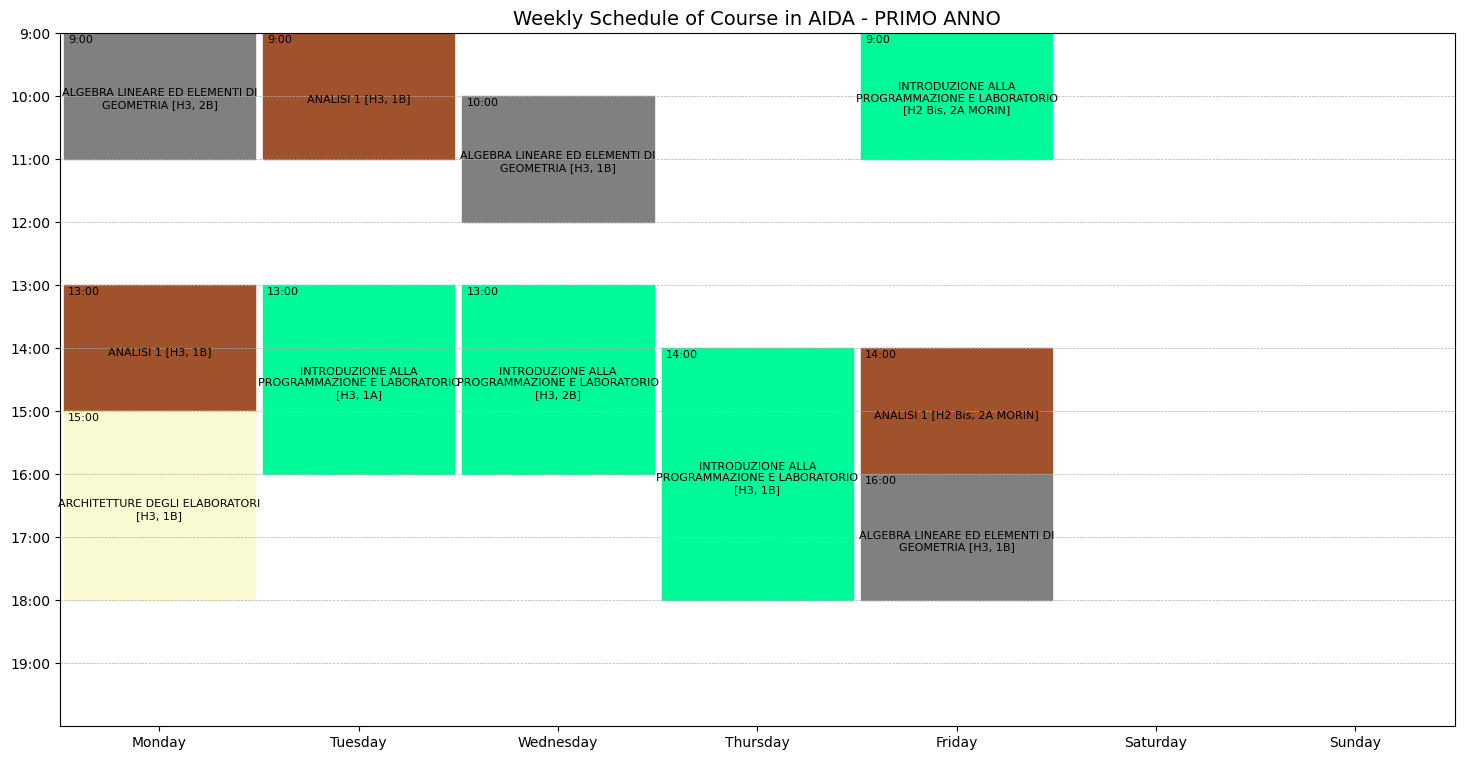

In [17]:
orario_aida.draw_calendar('AIDA', 'cds', 1)


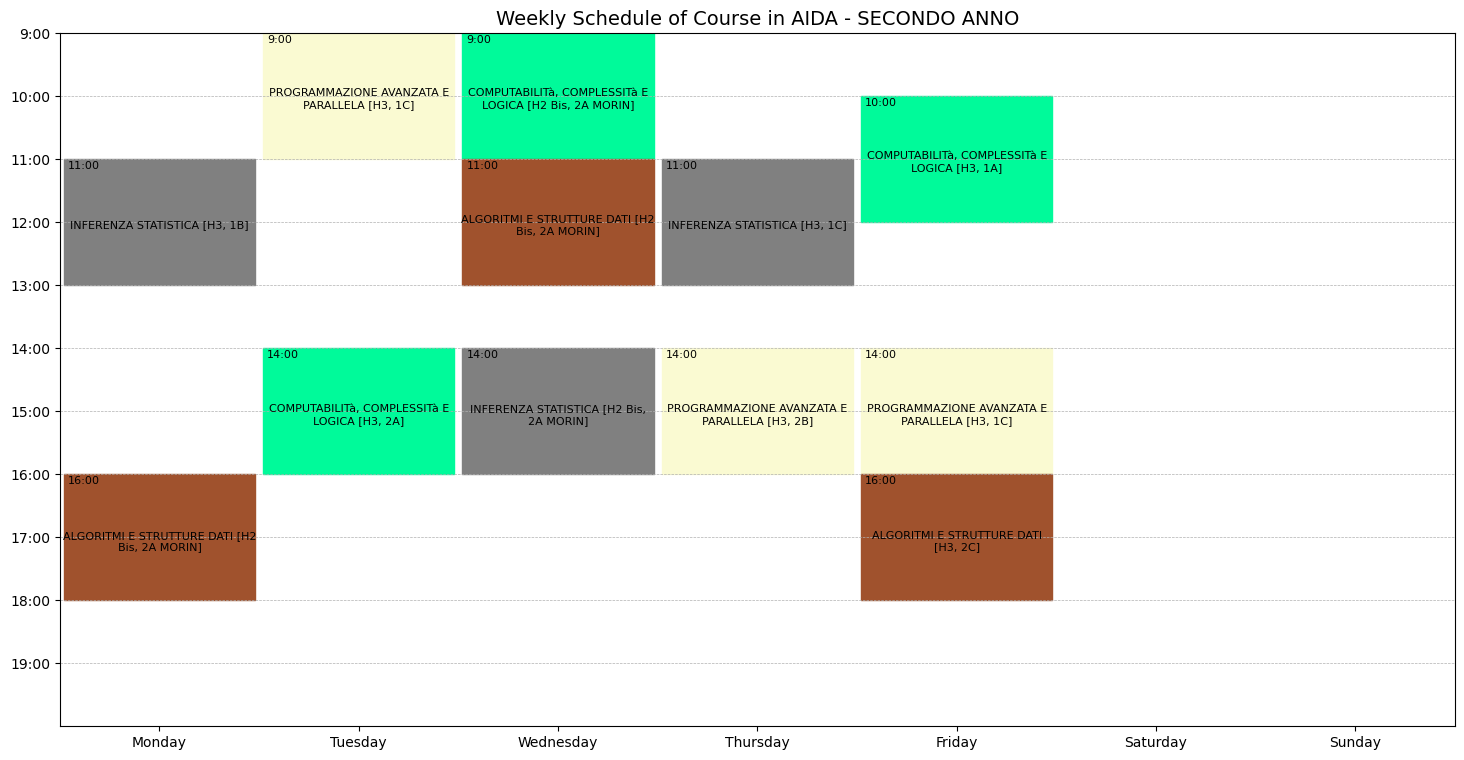

In [18]:
orario_aida.draw_calendar('AIDA', 'cds', 2)

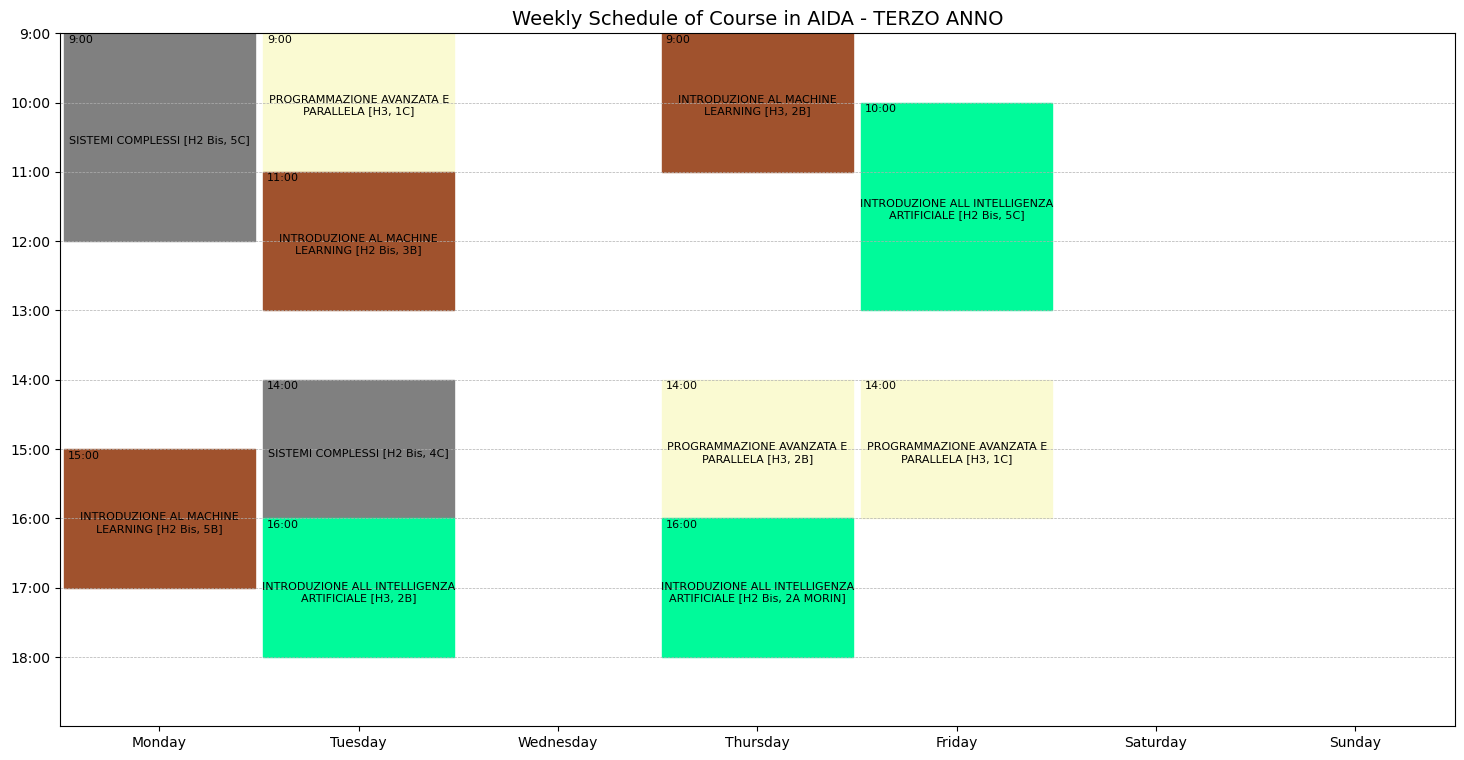

In [19]:
orario_aida.draw_calendar('AIDA', 'cds', 3)

In [20]:
orario_aida.end()

## Scenario 2: High School Timetable
Model creating a time table for the lessons of a class in high school, the last 3 years

*Modello che crea un orario settimanale per le lezioni del trienno di un liceo linguistico, solo per una classe (per semplicità assumiamo che tutti i professori siano assegnati ad una e sola sezione)*

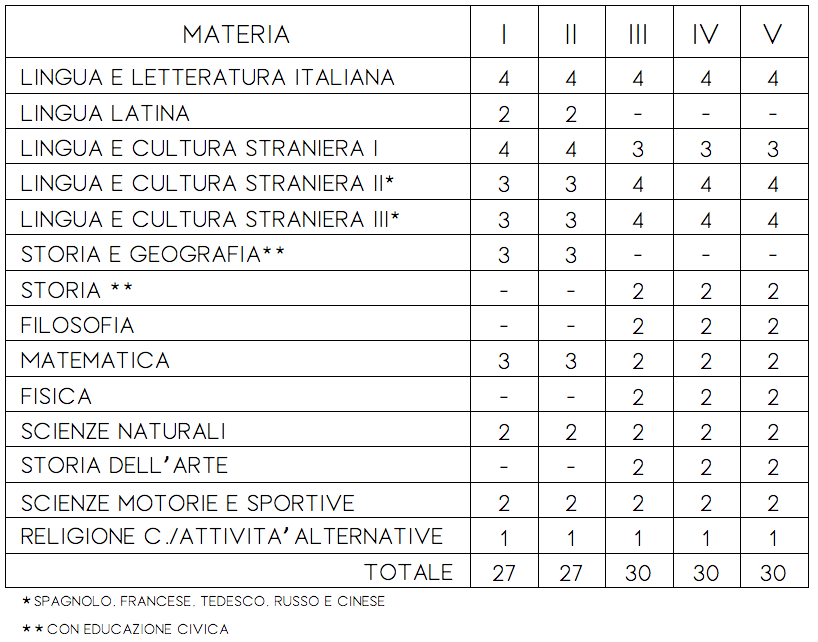
](https://www.istitutodantealighieri.it/wp-content/uploads/2023/01/quadro-LL-20-21.png)


Richieste specifiche:
- Nel quinto anno, le professoresse di Italiano e delle materie d'indirizzo (i.e. Inglese, Tedesco e Russo) hanno chiesto di ottenere uno slot da 3 ore, in un modo tale da consentire di svolgere delle esercitazioni della prima e seconda prova in vista della maturità.
- Inoltre, la professoressa di Storia e Filosofia ha chiesto di avere almeno uno slot da due ore, per delle motivazioni analoghe della prof. di Italiano.
- Tutte le classi hanno richiesto di avere le due ore di motoria attaccate, per evitare scomodità pratiche. 
- In vista agli esami di certificazioni delle lingue straniere Inglese e Tedesco, i professori hanno richiesto di ottenere almeno un slot da due ore per svolgere delle esercitazioni.

Tutte le richieste specifiche di cui sopra sono già state risolte con la progettazione del database

Vincoli specifici:
- Tutte le lezioni, tranne quelle di Motoria, saranno assegnate ad un'aula dedicata alla classe. Ad esempio, le lezioni di Italiano del 3° anno verranno assegnate solamente all'aula dedicata agli alunni del 3° anno.
- Esiste una sola aula per svolgere le lezioni di Motoria e quindi verrà condivisa tra le classi

In [21]:
liceo_timetable = TimetableScheduler('liceo', 5, optional_constraints=True)

In [22]:
liceo_timetable.start()

In [23]:
liceo_timetable.add_constraints()

In [ ]:
# Vincoli sulle aule

classi = liceo_timetable.indexes['CdS']
for classe in classi:
    corsi = liceo_timetable.database.get_courses(classe)
    for corso in corsi: 
        if corso in [1501, 2501, 3501]:
            continue # esclude motoria

        sessioni = liceo_timetable.database.get_sessions(corso)
        liceo_timetable.solver.add(
            And(
                [ Not(liceo_timetable.X[S, T, A]) for (S,T,A) in itertools.product(sessioni, liceo_timetable.T, liceo_timetable.indexes['Rooms']) if A != classe]
            
            )
        )
        

In [25]:
# Vincolo sulla palestra
sessioni_motoria = [
    i[0] for i in liceo_timetable.database.execute_query(
        """
            SELECT DISTINCT IDSession
            FROM Session
            WHERE IDCourse = 1501 OR IDCourse = 2501 OR IDCourse = 3501; 
        """
    )
]

liceo_timetable.solver.add(
    And(
        [Not(liceo_timetable.X[S, T, A]) for (S,T,A) in itertools.product(sessioni_motoria, liceo_timetable.T, liceo_timetable.indexes['Rooms']) if A in [1,2,3]]
    )
)

In [26]:
liceo_timetable.solve()

TIME TABLE SUCCESSFULLY CREATED
Saving the schedule in the SQL Database...
Schedule saved


In [27]:
from IPython.display import display, HTML 
df = liceo_timetable.print_schedule_df()
display(HTML(df.to_html().replace("\\n", "<br>")))

,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
08:00 - 09:00,> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO III]> TERZA LINGUA STRANIERA (RUSSO) [ANNO IV]> SCIENZE E MOTORIE SPORTIVE (ANNO V) [PALESTRA],> SCIENZE NATURALI [ANNO III]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO IV]> LINGUA E LETTERATURA ITALIANA [ANNO V],> FILOSOFIA [ANNO III]> LINGUA E LETTERATURA ITALIANA [ANNO IV]> MATEMATICA [ANNO V],> FILOSOFIA [ANNO III]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO IV]> SCIENZE NATURALI [ANNO V],> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO III]> MATEMATICA [ANNO IV]> TERZA LINGUA STRANIERA (RUSSO) [ANNO V],> SCIENZE E MOTORIE SPORTIVE (ANNO III) [PALESTRA]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO IV]> SCIENZE NATURALI [ANNO V]
09:00 - 10:00,> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO III]> TERZA LINGUA STRANIERA (RUSSO) [ANNO IV]> SCIENZE E MOTORIE SPORTIVE (ANNO V) [PALESTRA],> TERZA LINGUA STRANIERA (RUSSO) [ANNO III]> STORIA [ANNO IV]> MATEMATICA [ANNO V],> TERZA LINGUA STRANIERA (RUSSO) [ANNO III]> LINGUA E LETTERATURA ITALIANA [ANNO IV]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO V],> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO III]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO IV]> FILOSOFIA [ANNO V],> RELIGIONE CATTOCIA O ATTIVITA' ALTERNATIVE [ANNO III]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO IV]> TERZA LINGUA STRANIERA (RUSSO) [ANNO V],> SCIENZE E MOTORIE SPORTIVE (ANNO III) [PALESTRA]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO IV]> FISICA [ANNO V]
10:00 - 11:00,> MATEMATICA [ANNO III]> STORIA DELL'ARTE [ANNO IV]> LINGUA E LETTERATURA ITALIANA [ANNO V],> TERZA LINGUA STRANIERA (RUSSO) [ANNO III]> SCIENZE NATURALI [ANNO IV]> STORIA DELL'ARTE [ANNO V],> LINGUA E LETTERATURA ITALIANA [ANNO III]> MATEMATICA [ANNO IV]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO V],> STORIA DELL'ARTE [ANNO III]> FISICA [ANNO IV]> STORIA [ANNO V],> FISICA [ANNO III]> RELIGIONE CATTOCIA O ATTIVITA' ALTERNATIVE [ANNO IV]> TERZA LINGUA STRANIERA (RUSSO) [ANNO V],> LINGUA E LETTERATURA ITALIANA [ANNO III]> FISICA [ANNO IV]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO V]
11:00 - 12:00,> PRIMA LINGUA STRANIERA (INGLESE) [ANNO III]> STORIA [ANNO IV]> LINGUA E LETTERATURA ITALIANA [ANNO V],> STORIA [ANNO III]> TERZA LINGUA STRANIERA (RUSSO) [ANNO IV]> RELIGIONE CATTOCIA O ATTIVITA' ALTERNATIVE [ANNO V],> LINGUA E LETTERATURA ITALIANA [ANNO III]> SCIENZE E MOTORIE SPORTIVE (ANNO IV) [PALESTRA]> PRIMA LINGUA STRANIERA (INGLESE) [ANNO V],> PRIMA LINGUA STRANIERA (INGLESE) [ANNO III]> SCIENZE NATURALI [ANNO IV]> STORIA [ANNO V],> TERZA LINGUA STRANIERA (RUSSO) [ANNO III]> LINGUA E LETTERATURA ITALIANA [ANNO IV]> STORIA DELL'ARTE [ANNO V],> LINGUA E LETTERATURA ITALIANA [ANNO III]> FILOSOFIA [ANNO IV]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO V]
12:00 - 13:00,> PRIMA LINGUA STRANIERA (INGLESE) [ANNO III]> FILOSOFIA [ANNO IV]> LINGUA E LETTERATURA ITALIANA [ANNO V],> STORIA DELL'ARTE [ANNO III]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO IV]> FILOSOFIA [ANNO V],> MATEMATICA [ANNO III]> SCIENZE E MOTORIE SPORTIVE (ANNO IV) [PALESTRA]> TERZA LINGUA STRANIERA (RUSSO) [ANNO V],> SCIENZE NATURALI [ANNO III]> TERZA LINGUA STRANIERA (RUSSO) [ANNO IV]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO V],> STORIA [ANNO III]> LINGUA E LETTERATURA ITALIANA [ANNO IV]> FISICA [ANNO V],> FISICA [ANNO III]> STORIA DELL'ARTE [ANNO IV]> SECONDA LINGUA STRANIERA (TEDESCO) [ANNO V]


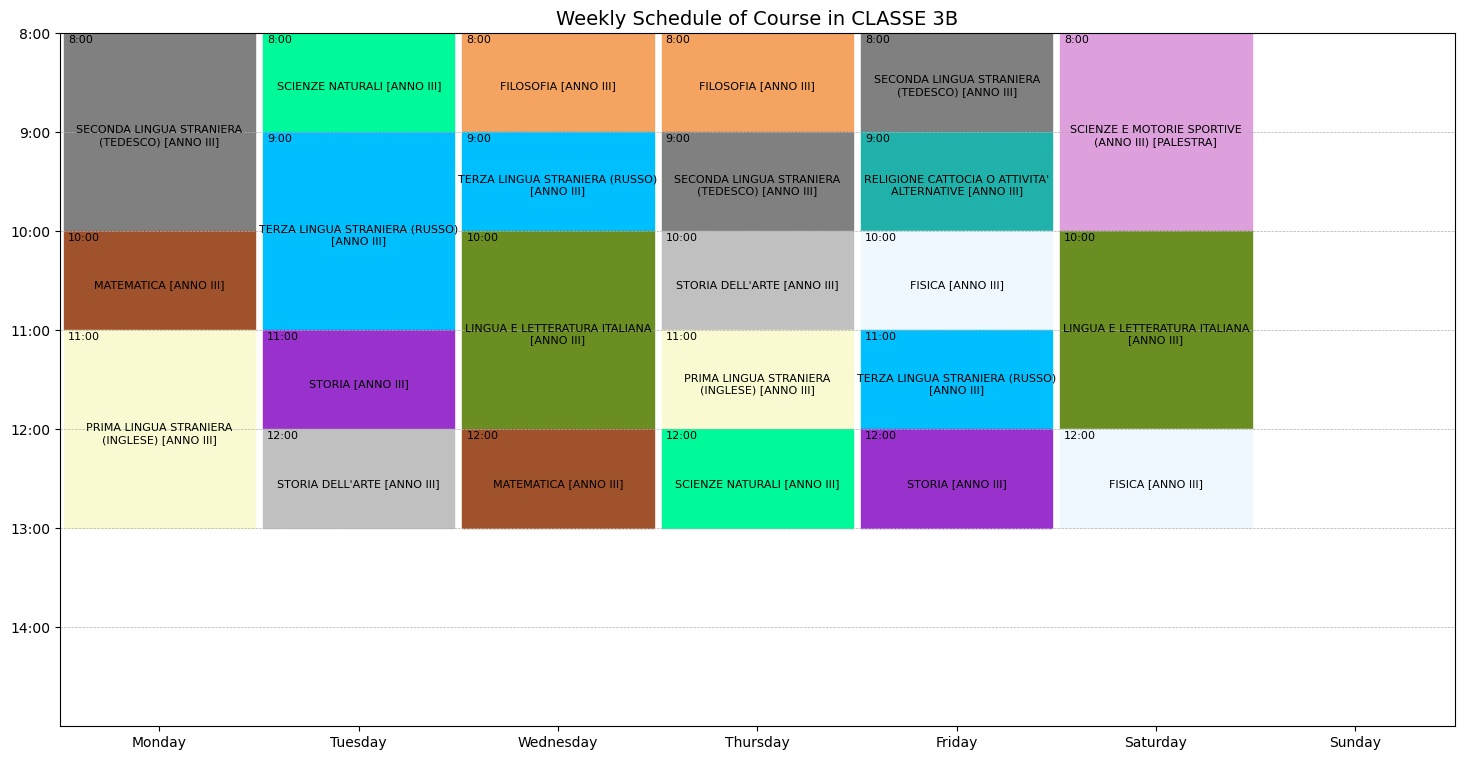

In [28]:
liceo_timetable.draw_calendar('Liceo F. Da Collo', 'cds', 1)

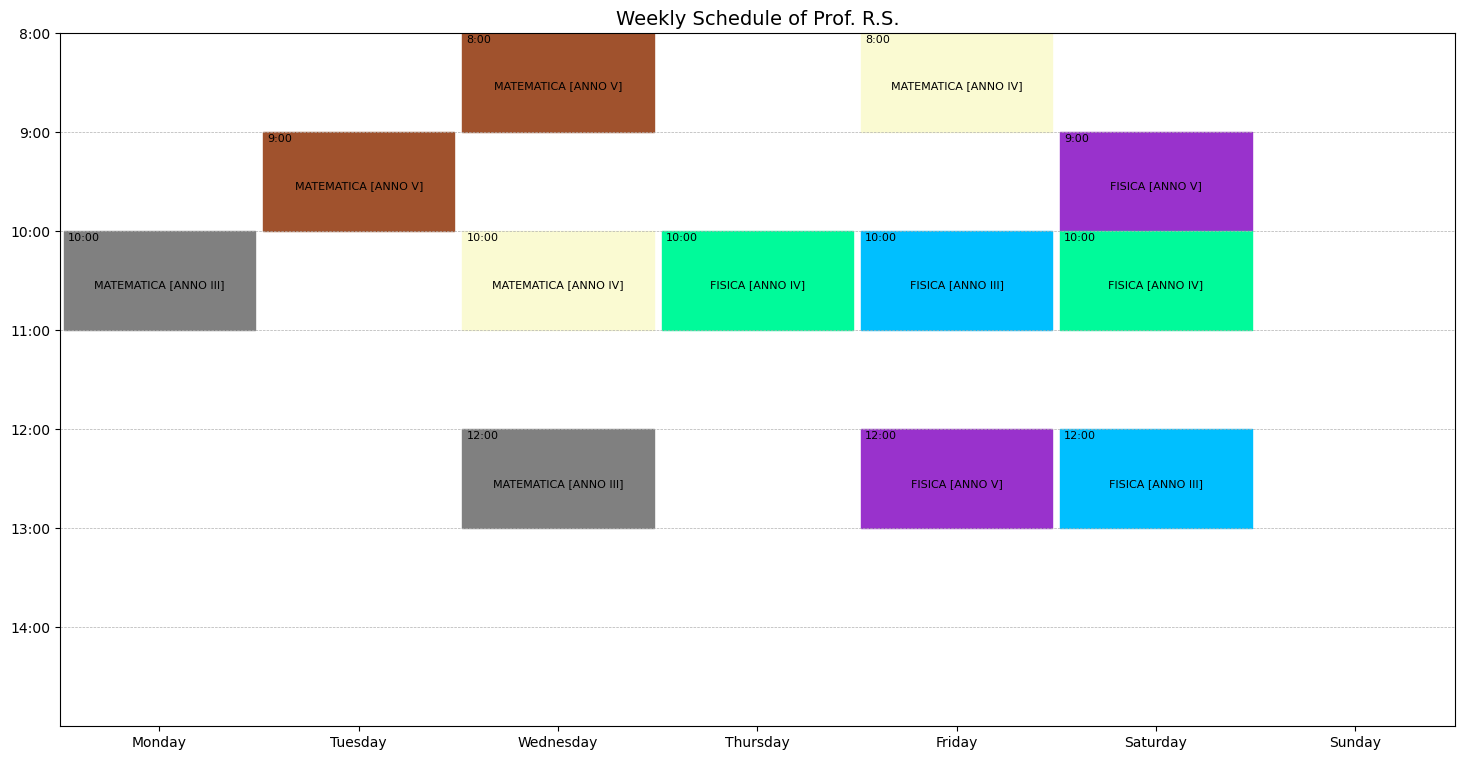

In [29]:
liceo_timetable.draw_calendar('Liceo F. Da Collo', 'prof', 6)

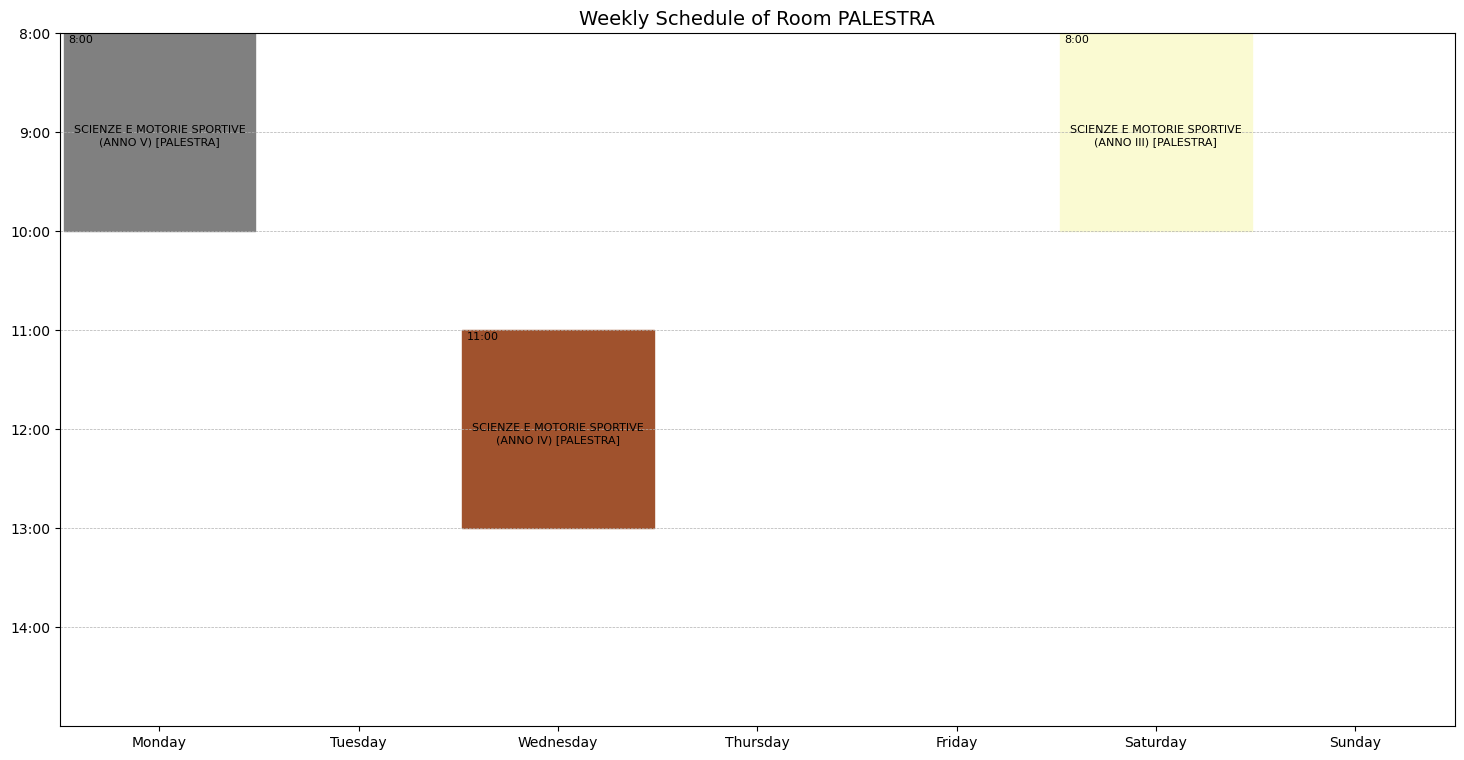

In [30]:
liceo_timetable.draw_calendar('Liceo F. Da Collo', 'room', 4)

In [31]:
liceo_timetable.end()

Fine della demo